«Исследование и сравнение методов понижения размерности и кластеризации на реальном высокоразмерном датасете (из области по выбору: биоинформатика, тексты, изображения, графы) с анализом устойчивости и интерпретируемости полученных кластеров».

Основные требования к проекту:

Выбор и обоснование одного или двух реальных высокоразмерных датасетов (например, single‑cell RNA‑seq, embedding‑представления текстов, feature‑описания изображений)
Построение и сравнение нескольких пайплайнов «DR → кластеризация» (минимум 3 DR‑метода и 3 алгоритма кластеризации) с оценкой качества, устойчивости и практической интерпретации кластеров.

In [42]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import permutations

# Sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS, SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, adjusted_mutual_info_score, 
    homogeneity_completeness_v_measure, accuracy_score
)
import umap



In [44]:

cat = ['sci.space', 'alt.atheism', 'comp.windows.x']

data = fetch_20newsgroups(subset='all', categories=cat, remove=('headers', 'footers', 'quotes'))

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.6,
    stop_words='english',
    ngram_range=(1, 2)
)
X_raw = vectorizer.fit_transform(data.data)
feature_names = vectorizer.get_feature_names_out()
y_true = data.target

print(f" Матрица признаков: {X_raw.shape}")
print(f"Классы: {dict(zip(range(len(cat)), cat))}")
print(f"Распределение классов: {np.bincount(y_true)}")

 Матрица признаков: (2774, 5000)
Классы: {0: 'sci.space', 1: 'alt.atheism', 2: 'comp.windows.x'}
Распределение классов: [799 988 987]


Понижение размерности (DR)

In [45]:
from sklearn.decomposition import TruncatedSVD

dr_50d = {}
dr_2d = {}

# SVD (LSA)
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_raw)

dr_50d['SVD_50D'] = X_svd[:, :50]
dr_2d['SVD_2D'] = X_svd[:, :2]

# PCA
X_dense = X_raw.toarray()
pca = PCA(n_components=50, random_state=42)
dr_50d['PCA_50D'] = pca.fit_transform(X_dense)
dr_2d['PCA_2D'] = dr_50d['PCA_50D'][:, :2]

# UMAP
dr_50d['UMAP_50D'] = umap.UMAP(n_components=50, random_state=42).fit_transform(X_svd)
dr_2d['UMAP_2D'] = umap.UMAP(n_components=2, random_state=42).fit_transform(X_svd)

# t-SNE только для визуализации
dr_2d['tSNE_2D'] = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
).fit_transform(X_svd)

c:\Users\A1ex5\Desktop\CodeFlow\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\A1ex5\Desktop\CodeFlow\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


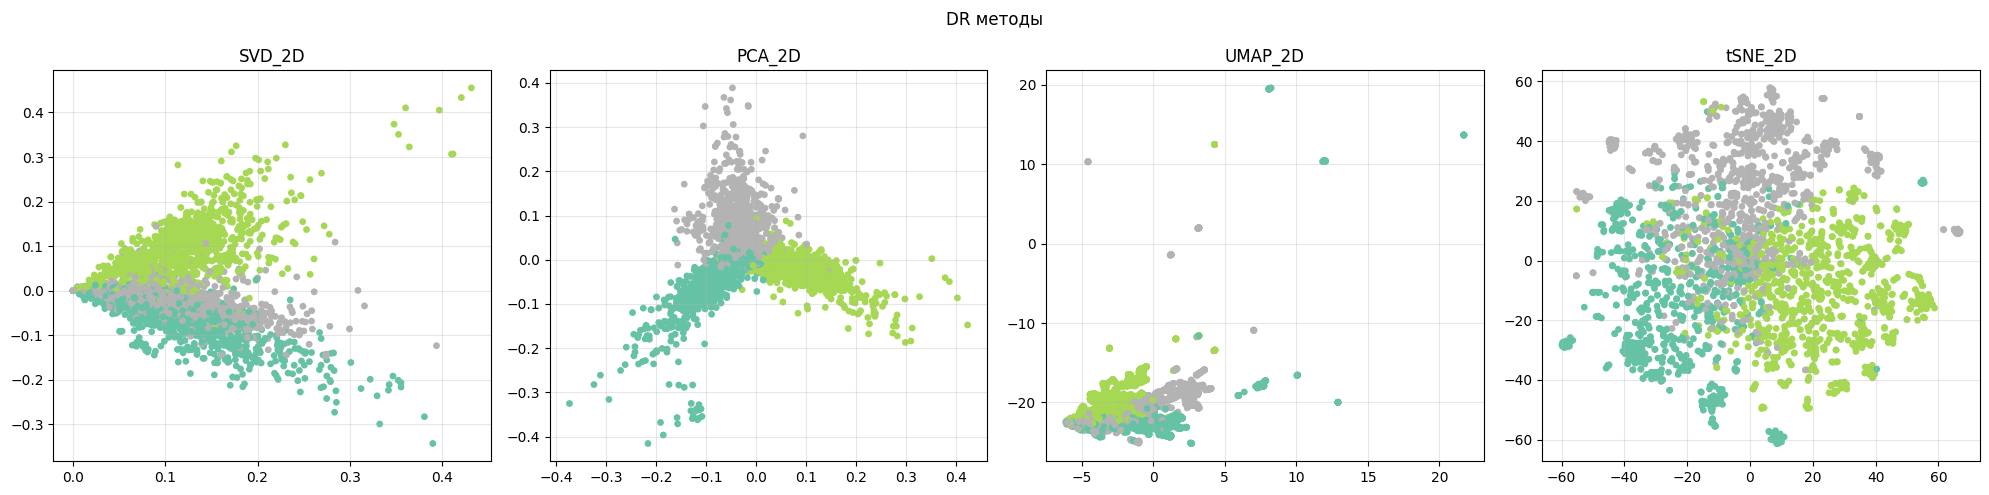

In [46]:
fig, axes = plt.subplots(1, len(dr_2d), figsize=(20, 5))

for ax, (name, X) in zip(axes, dr_2d.items()):
    ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='Set2', s=15)
    ax.set_title(name)
    ax.grid(alpha=0.3)

plt.suptitle("DR методы")
plt.tight_layout()
plt.show()

Кластеризация

In [47]:
clusterers = {
    'KMeans': lambda X, k=3: KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X),
    'Agglomerative': lambda X, k=3: AgglomerativeClustering(n_clusters=k).fit_predict(X),
    'GMM': lambda X, k=3: GaussianMixture(n_components=k, random_state=42).fit_predict(X),
    'DBSCAN': lambda X, k=3: DBSCAN(eps=0.5, min_samples=5).fit_predict(X)
}

results = []

for dr_name, X in dr_50d.items():
    print(f"\nDR: {dr_name}")
    
    for algo_name, algo in clusterers.items():
        try:
            labels = algo(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            if n_clusters < 2:
                continue

            sil = silhouette_score(X, labels)
            db = davies_bouldin_score(X, labels)
            ari = adjusted_rand_score(y_true, labels)

            results.append({
                "DR": dr_name,
                "Algorithm": algo_name,
                "Clusters": n_clusters,
                "Silhouette": sil,
                "DaviesBouldin": db,
                "ARI": ari
            })

            print(f"{algo_name}: ARI={ari:.3f}")

        except:
            pass

results_df = pd.DataFrame(results).sort_values("ARI", ascending=False)
results_df


DR: SVD_50D
KMeans: ARI=0.391
Agglomerative: ARI=0.338
GMM: ARI=-0.001
DBSCAN: ARI=0.001

DR: PCA_50D
KMeans: ARI=0.425
Agglomerative: ARI=0.306
GMM: ARI=0.342
DBSCAN: ARI=0.001

DR: UMAP_50D
KMeans: ARI=0.237
Agglomerative: ARI=0.154
GMM: ARI=0.002
DBSCAN: ARI=0.013


,DR,Algorithm,Clusters,Silhouette,DaviesBouldin,ARI
4,PCA_50D,KMeans,3,0.092088,2.965430,0.425156
0,SVD_50D,KMeans,3,0.092670,2.919209,0.390957
6,PCA_50D,GMM,3,0.030951,3.537033,0.342108
1,SVD_50D,Agglomerative,3,0.077342,3.144544,0.337742
5,PCA_50D,Agglomerative,3,0.092559,3.118130,0.306362
8,UMAP_50D,KMeans,3,0.270032,1.381564,0.236619
9,UMAP_50D,Agglomerative,3,0.251992,1.512254,0.153883
11,UMAP_50D,DBSCAN,32,-0.166583,1.001613,0.012627
10,UMAP_50D,GMM,3,0.801690,0.785180,0.001926
3,SVD_50D,DBSCAN,3,0.415875,0.523527,0.000960


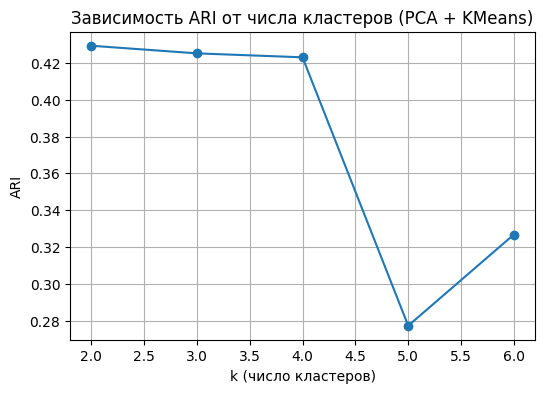

In [48]:
k_values = range(2, 7)
ari_scores = []

X_best = dr_50d['PCA_50D']

for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X_best)
    ari = adjusted_rand_score(y_true, labels)
    ari_scores.append(ari)

plt.figure(figsize=(6,4))
plt.plot(k_values, ari_scores, marker='o')
plt.xlabel("k (число кластеров)")
plt.ylabel("ARI")
plt.title("Зависимость ARI от числа кластеров (PCA + KMeans)")
plt.grid()
plt.show()

In [50]:
best_dr = results_df.iloc[0]["DR"]
best_algo = results_df.iloc[0]["Algorithm"]

X_best = dr_50d[best_dr]
labels = clusterers[best_algo](X_best)

print("\nИнтерпретация лучших кластеров\n")

for cluster_id in range(3):
    mask = labels == cluster_id
    cluster_mean = X_raw[mask].mean(axis=0)
    cluster_mean = np.asarray(cluster_mean).ravel()

    top_idx = cluster_mean.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx[:5]]

    true_dist = np.bincount(y_true[mask])
    dominant = cat[true_dist.argmax()]

    print(f"\nCluster {cluster_id}")
    print("Top words:", ", ".join(top_words))
    print("Dominant class:", dominant)


Интерпретация лучших кластеров


Cluster 0
Top words: stay blew, manhattan, bronx, manhattan sea, sank manhattan
Dominant class: sci.space

Cluster 1
Top words: window, thanks, server, use, motif
Dominant class: alt.atheism

Cluster 2
Top words: space, just, think, don, people
Dominant class: comp.windows.x


In [51]:
def bootstrap_stability(X, y, dr_func, cluster_func, n_iter=10):
    ari_scores = []
    n = X.shape[0]
    rng = np.random.RandomState(42)
    
    for _ in range(n_iter):
        idx = rng.choice(n, int(n * 0.8), replace=True)
        X_sample = X[idx]
        y_sample = y[idx]
        
        X_dr = dr_func(X_sample)
        labels = cluster_func(X_dr)
        
        if len(set(labels)) > 1:
            ari_scores.append(adjusted_rand_score(y_sample, labels))
    
    return np.mean(ari_scores), np.std(ari_scores)

mean_ari, std_ari = bootstrap_stability(
    X_raw,
    y_true,
    lambda X: TruncatedSVD(n_components=50, random_state=42).fit_transform(X),
    lambda X: KMeans(n_clusters=3, random_state=42).fit_predict(X)
)

print(f"\nBootstrap ARI = {mean_ari:.3f} ± {std_ari:.3f}")


Bootstrap ARI = 0.280 ± 0.161


Почему PCA показал лучший результат, чем SVD?

* PCA оптимизирует глобальную дисперсию данных, что может способствовать лучшему разделению кластеров в евклидовом пространстве при использовании KMeans.
* SVD (LSA) сохраняет латентную семантическую структуру, однако при сильном тематическом перекрытии классов это может сглаживать границы между ними.

Почему UMAP показал худшие результаты?

* UMAP оптимизирует локальную структуру многообразия, а не глобальную кластерную разделимость.
Он эффективен для визуализации, но не гарантирует сохранение евклидовой геометрии, необходимой для KMeans. Поэтому ARI оказался ниже.


* Bootstrap показал высокое стандартное отклонение ARI (~0.16), что говорит о чувствительности модели к подвыборке данных. Это указывает на частичное перекрытие тематик в текстовом корпусе.

* TF-IDF не учитывает контекст.

* Евклидова метрика плохо отражает семантическое расстояние.

* Кластеры не обязаны совпадать с размеченными классами.

* DR методы могут искажать структуру пространства.